# **Predict a person’s medical insurance cost based on their personal details.**


Data Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Test RMSE: 5796.28
Test R2 Score: 0.7836


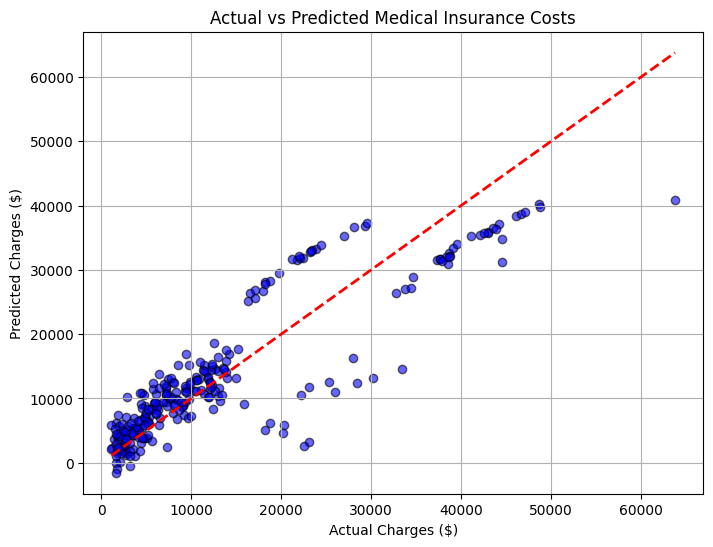

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Medical Cost Personal Datasets.csv")
print("Data Shape:", df.shape)
print(df.head())

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
numerical_cols = ['age', 'bmi', 'children']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2 Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Medical Insurance Costs')
plt.grid(True)
plt.show()

## **Predict whether a customer will churn (leave the company) based on their behavior and usage patterns.**

Accuracy : 0.7743
Precision: 0.5927
Recall   : 0.4786
F1-Score : 0.5296


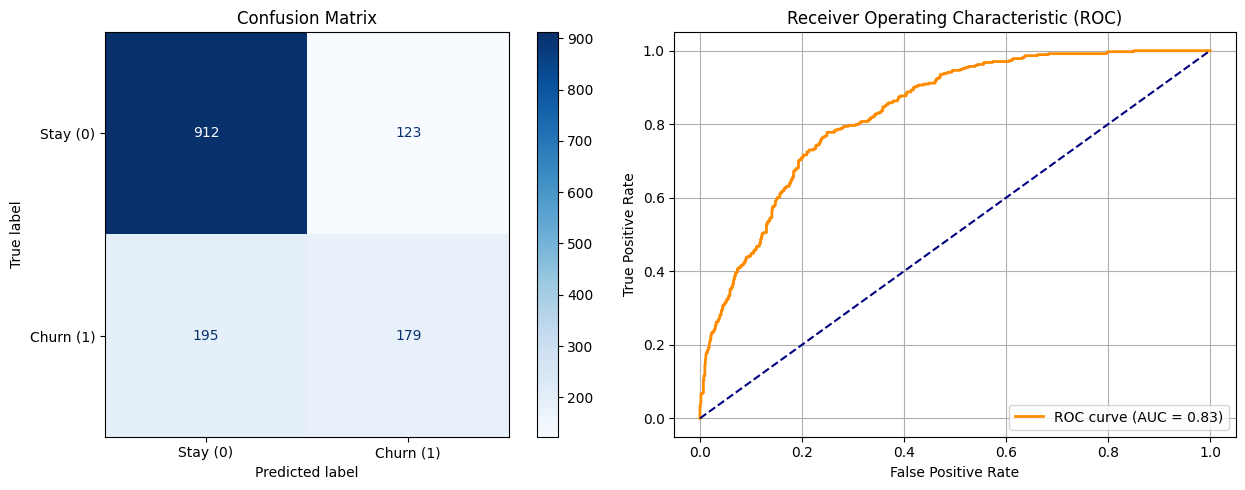

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

df = pd.read_csv("Telco Customer Churn.csv")

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService']
X = df[features].copy()
y = df['Churn']

X = pd.get_dummies(X, columns=['Contract', 'InternetService'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
scale_cols = ['tenure', 'MonthlyCharges']
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
disp.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc_val:.2f})")
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Predict used car prices based on mileage, age, and horsepower.



--- Model Comparison on Test Set ---
                     RMSE        R2
Linear        4066.856372  0.790493
Poly (deg=2)  3986.069984  0.798734
Poly (deg=3)  4725.355977  0.717154
Poly (deg=4)  7167.169313  0.349307


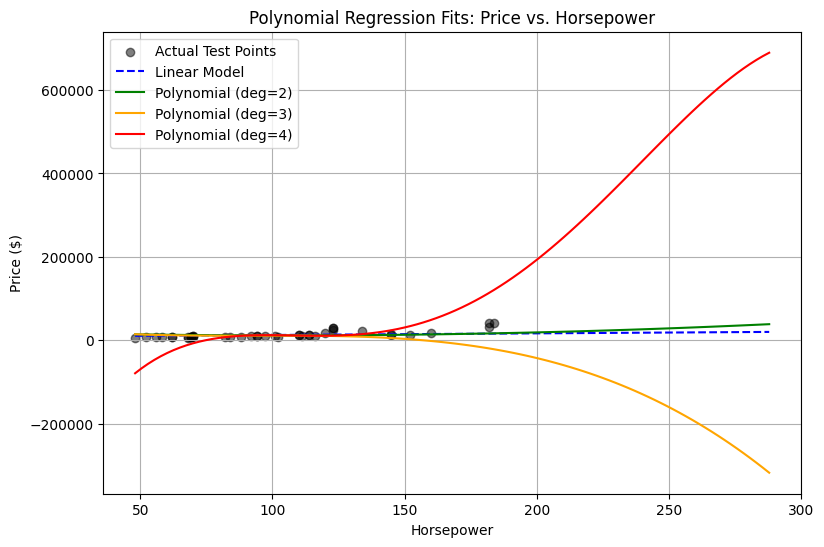

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("Car Price Prediction.csv")


features = ['horsepower', 'enginesize', 'citympg']
target = 'price'

X = df[features].values
y = df[target].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

results = {
    "Linear": {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        "R2": r2_score(y_test, y_pred_lin)
    }
}

degrees = [2, 3, 4]
fitted_models = {}

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred_poly = model.predict(X_test_poly)

    results[f"Poly (deg={d})"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        "R2": r2_score(y_test, y_pred_poly)
    }
    fitted_models[d] = (poly, model)

metrics_df = pd.DataFrame(results).T
print("\n--- Model Comparison on Test Set ---")
print(metrics_df)

plt.figure(figsize=(9, 6))

plt.scatter(X_test[:, 0], y_test, color='black', alpha=0.5, label='Actual Test Points')

hp_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
median_engine = np.median(X[:, 1])
median_mpg = np.median(X[:, 2])

X_synthetic = np.column_stack([
    hp_range,
    np.full_like(hp_range, median_engine),
    np.full_like(hp_range, median_mpg)
])

plt.plot(hp_range, lin_reg.predict(X_synthetic), label='Linear Model', linestyle='--', color='blue')

colors = ['green', 'orange', 'red']
for d, color in zip(degrees, colors):
    poly, p_model = fitted_models[d]
    X_synth_poly = poly.transform(X_synthetic)
    plt.plot(hp_range, p_model.predict(X_synth_poly), label=f'Polynomial (deg={d})', color=color)

plt.xlabel('Horsepower')
plt.ylabel('Price ($)')
plt.title('Polynomial Regression Fits: Price vs. Horsepower')
plt.legend()
plt.grid(True)
plt.show()